# 01 — Exploratory Data Analysis

CommerceIQ: revenue trend, category performance, customer distribution, geographic performance, and a couple of statistical checks (SQL answers *what* happened; this notebook explores *why* it might have).

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from db import get_engine

sns.set_theme(style="whitegrid")
engine = get_engine()
pd.options.display.float_format = '{:,.2f}'.format


## Revenue trend

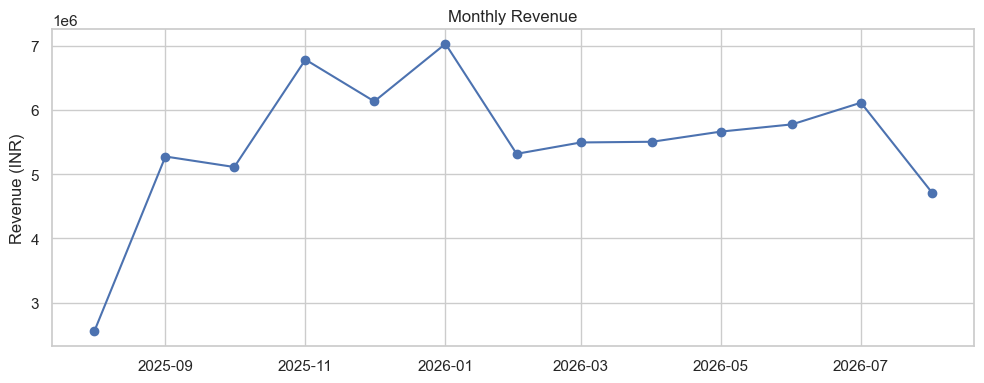

In [2]:
monthly = pd.read_sql('''
    SELECT DATE_TRUNC('month', o.order_date)::date AS month,
           SUM(o.quantity * p.selling_price * (1 - o.discount)) AS revenue
    FROM orders o JOIN products p ON p.product_id = o.product_id
    WHERE o.order_status <> 'Cancelled'
    GROUP BY 1 ORDER BY 1
''', engine)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly['month'], monthly['revenue'], marker='o')
ax.set_title('Monthly Revenue')
ax.set_ylabel('Revenue (INR)')
plt.tight_layout()
plt.show()


## Category performance

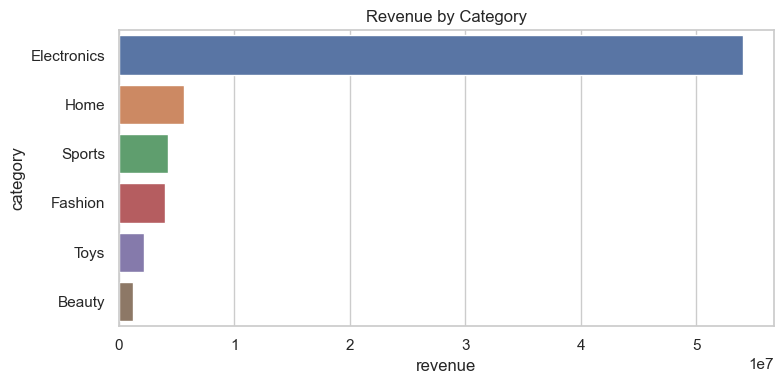

,category,revenue
0,Electronics,"54,036,430.87"
1,Home,"5,625,363.01"
2,Sports,"4,254,965.19"
3,Fashion,"4,015,030.03"
4,Toys,"2,222,880.90"
5,Beauty,"1,279,532.70"


In [3]:
category = pd.read_sql('''
    SELECT p.category, SUM(o.quantity * p.selling_price * (1 - o.discount)) AS revenue
    FROM orders o JOIN products p ON p.product_id = o.product_id
    WHERE o.order_status <> 'Cancelled'
    GROUP BY p.category ORDER BY revenue DESC
''', engine)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=category, x='revenue', y='category', ax=ax, hue='category', legend=False)
ax.set_title('Revenue by Category')
plt.tight_layout()
plt.show()
category


## Customer age distribution

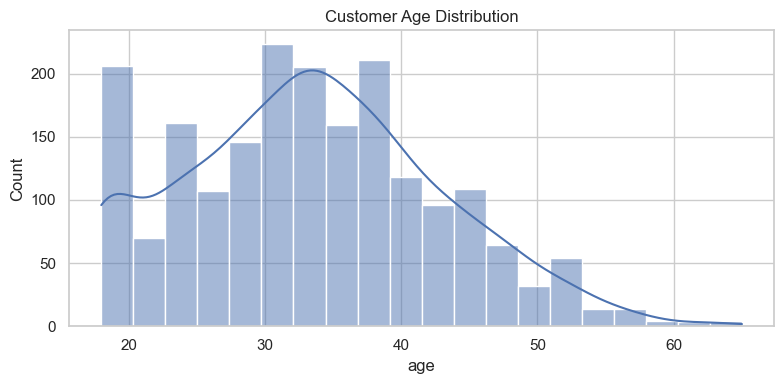

count   2,000.00
mean       33.50
std         9.36
min        18.00
25%        27.00
50%        33.00
75%        40.00
max        65.00
Name: age, dtype: float64

In [4]:
customers = pd.read_sql('SELECT age, gender, state FROM customers', engine)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=customers, x='age', bins=20, kde=True, ax=ax)
ax.set_title('Customer Age Distribution')
plt.tight_layout()
plt.show()
customers['age'].describe()


## Geographic performance (top 10 states by revenue)

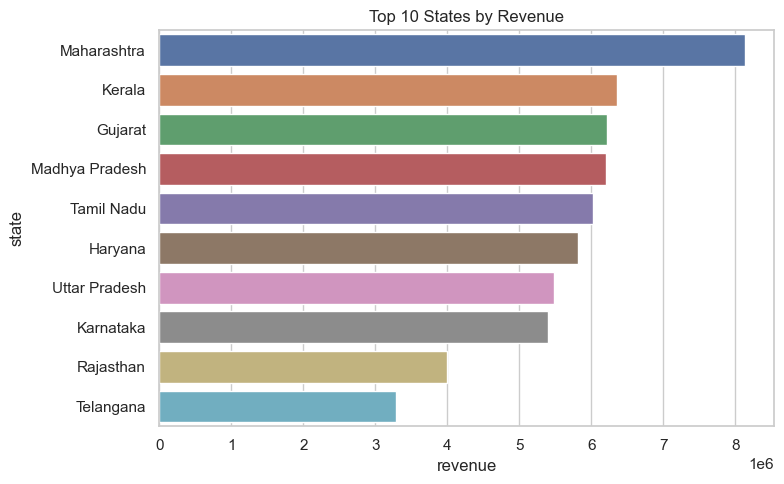

In [5]:
geo = pd.read_sql('''
    SELECT c.state, SUM(o.quantity * p.selling_price * (1 - o.discount)) AS revenue
    FROM orders o
    JOIN products p ON p.product_id = o.product_id
    JOIN customers c ON c.customer_id = o.customer_id
    WHERE o.order_status <> 'Cancelled'
    GROUP BY c.state ORDER BY revenue DESC LIMIT 10
''', engine)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=geo, x='revenue', y='state', ax=ax, hue='state', legend=False)
ax.set_title('Top 10 States by Revenue')
plt.tight_layout()
plt.show()


## Does more pages viewed correlate with purchasing?

Point-biserial correlation between `pages_viewed` (continuous) and `purchased` (binary) on website session data.

In [6]:
sessions = pd.read_sql('SELECT pages_viewed, session_duration, purchased FROM website_sessions', engine)
r, p = stats.pointbiserialr(sessions['purchased'].astype(int), sessions['pages_viewed'])
print(f"Point-biserial r = {r:.3f}, p-value = {p:.4f}")
print("Interpretation: statistically significant positive relationship" if p < 0.05
      else "Interpretation: not statistically significant at alpha=0.05")


Point-biserial r = 0.062, p-value = 0.0000
Interpretation: statistically significant positive relationship
